In [1]:
!pip install torch
!pip install triton

In [2]:
import torch
import triton
import triton.language as tl
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [13]:
@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr
):
  #to which part I am allocated?
  PID = tl.program_id(axis=0)
  #vec of length 256
  #block_size 64
  #pid 0 might process elements [0:64]
  #pid 1 might process elements [64: 128]...

  block_start = PID * BLOCK_SIZE
  offsets = block_start + tl.arange(0, BLOCK_SIZE) #to mark all the elements in the block
  #mask tells us how much elements we want to actually work on:
  mask = offsets < n_elements

  #load data from dram/vram/hbm to sram/on-chip memory
  x = tl.load(x_ptr + offsets, mask = mask, other=None) #shape = (BLOCK_SIZE)
  y = tl.load(y_ptr + offsets, mask = mask)

  output = x + y

  #write data back to dram
  tl.store(output_ptr + offsets, output, mask=mask)

def add(x, y):
  #pre-allocate the output
  output = torch.empty_like(x)

  #check whether tensors are on the same device
  # assert x.device == DEVICE and y.device == DEVICE

  n_elements = output.numel()
  grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)

  add_kernel[grid](
      x,
      y,
      output,
      n_elements,
      BLOCK_SIZE = 1024,
  )

  return output



def test_add_kernel(size, atol=1e-3, rtol=1e-3, device=DEVICE):
  #create test data
  torch.manual_seed(0)
  x = torch.randn(size, device=device)
  y = torch.randn(size, device=device)

  #run the kernel
  z_triton = add(x, y) #triton kernel
  z_ref = x+y #pytorch equivalent

  #compare
  torch.testing.assert_close(z_triton, z_ref, rtol=rtol, atol=atol)
  print("passed")

In [17]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(12, 24, 1)],
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'pytorch'],
        line_names=['Triton', 'PyTorch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='vector-add-performance',
        args={},
    )
)
def benchmark(size, provider):
  #create input data
  x = torch.randn(size, device=DEVICE, dtype = torch.float32)
  y = torch.randn(size, device=DEVICE, dtype = torch.float32)

  quantiles = [0.5, 0.05, 0.95]

  if provider == 'torch':
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: x+y, quantiles=quantiles)
  if provider == 'triton':
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)

  gbps = lambda ms: 3* x.numel() * x.element_size() * 1e-9/ (ms * 1e-3)

  return gbps(ms), gbps(min_ms), gbps(max_ms)
  #run the kernel


In [18]:
test_add_kernel(size = 4096)
test_add_kernel(size = 98432)

passed
passed


In [19]:
!pip install numpy matplotlib pandas pytest

In [21]:
import sys

# if len(sys.argv) > 1 and sys.argv[1] == '--benchmark':
benchmark.run(save_path='.', print_data=True)

UnboundLocalError: cannot access local variable 'ms' where it is not associated with a value

In [15]:
!nvidia-smi

Wed Mar 18 09:35:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             28W /   70W |     125MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
# Cell A: definitions
import math, time
import torch
import triton
import triton.language as tl
import triton.testing

DEVICE = 'cuda'

# Triton add kernel
@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr
):
    PID = tl.program_id(0)
    block_start = PID * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    # use numeric 'other' when masked
    x = tl.load(x_ptr + offsets, mask=mask, other=0.0)   # shape = (BLOCK_SIZE)
    y = tl.load(y_ptr + offsets, mask=mask, other=0.0)

    output = x + y
    tl.store(output_ptr + offsets, output, mask=mask)

def add(x, y, block_size=1024):
    output = torch.empty_like(x)
    n_elements = output.numel()
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=block_size)
    return output

def test_add_kernel(size, atol=1e-3, rtol=1e-3, device=DEVICE):
    torch.manual_seed(0)
    x = torch.randn(size, device=device)
    y = torch.randn(size, device=device)
    z_triton = add(x, y)
    z_ref = x + y
    torch.testing.assert_close(z_triton, z_ref, rtol=rtol, atol=atol)
    print(f"test_add_kernel({size}): passed")

# perf_report benchmark
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(12, 24, 1)],
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'pytorch'],
        line_names=['Triton', 'PyTorch'],
        styles=[('blue', '-'), ('green', '-')],
        ylabel='GB/s',
        plot_name='vector-add-performance',
        args={},
    )
)
def benchmark(size, provider):
    x = torch.randn(size, device=DEVICE, dtype=torch.float32)
    y = torch.randn(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.05, 0.95]

    # Match exactly the strings in line_vals ('pytorch' and 'triton')
    if provider == 'pytorch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    elif provider == 'triton':
        # run Triton add (wrap in a callable for do_bench)
        def run_triton():
            # call kernel; uses x,y from outer scope
            out = torch.empty_like(x)
            N = x.numel()
            block = 1024
            grid = (math.ceil(N / block),)
            add_kernel[grid](x, y, out, N, BLOCK_SIZE=block)
            torch.cuda.synchronize()
            return out
        ms, min_ms, max_ms = triton.testing.do_bench(run_triton, quantiles=quantiles)
    else:
        raise ValueError(f"Unknown provider: {provider}")

    gbps = lambda t_ms: 3 * x.numel() * x.element_size() * 1e-9 / (t_ms * 1e-3)  # read x+y and write out => 3 * bytes
    return gbps(ms), gbps(min_ms), gbps(max_ms)

test_add_kernel(4096): passed
test_add_kernel(98432): passed
vector-add-performance:
         size  Triton (GB/s)  PyTorch (GB/s)
0      4096.0       1.623679        6.826667
1      8192.0       1.184728       20.344371
2     16384.0       2.395789       41.373737
3     32768.0       4.442516       67.889504
4     65536.0      25.653444       96.000000
5    131072.0      48.000000      141.852818
6    262144.0      80.842109      182.044451
7    524288.0     118.153847      204.800005
8   1048576.0     157.791325      219.428568
9   2097152.0     190.603975      228.880087
10  4194304.0     208.271180      234.057145
11  8388608.0     223.680302      236.307695


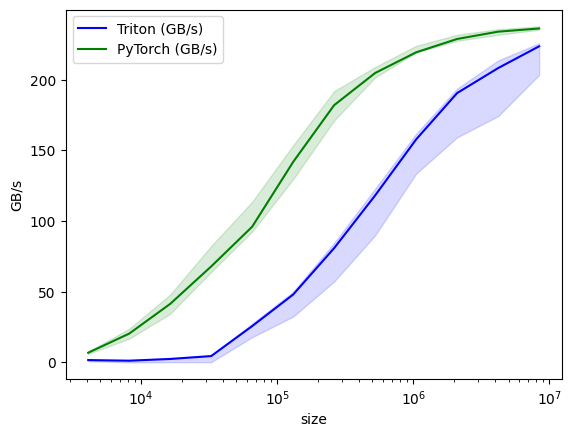

In [23]:
# Cell B: run tests + benchmark
test_add_kernel(size=4096)
test_add_kernel(size=98432)   # may be large — skip or reduce if OOM

# Run the perf_report (this will create the plots and saved results)
benchmark.run(save_path='.', print_data=True)